In [15]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from ngram_model import *
from game import *

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['figure.figsize'] = (5.5, 3.5)

data set up

In [2]:
corpus = load_corpus('words_alpha.txt')
train_set, test_set = train_test_split(corpus, 0.95)
train_set, held_out = train_test_split(train_set, 0.9)

Train models

In [3]:
models = {}
for n in range(1, 4):
    padded = process(train_set, n)
    models[n] = train(padded, n)

lambdas = optimize_lambdas(held_out, models, step=0.1) #took ~3 mins at .05

In [4]:
#sets lambda for each kind of gram
configs = {
    'Unigram': {1: 1.0, 2: 0.0, 3: 0.0},
    'Bigram': {1: 0.0, 2: 1.0, 3: 0.0},
    'Trigram': {1: 0.0, 2: 0.0, 3: 1.0},
    'Interpolated': lambdas
}

intrisic comps

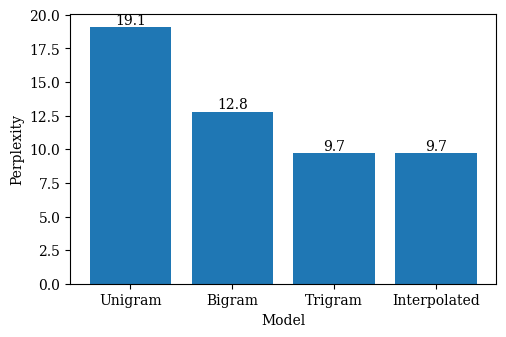

{1: 0.0, 2: 0.0, 3: 1.0}


In [5]:
labels = []
pp_values = []
for name, lam in configs.items():
    pp = perplexity(test_set, models, lam)
    labels.append(name)
    pp_values.append(pp)

plt.bar(labels, pp_values)
for i, v in enumerate(pp_values):
    plt.text(i, v, f'{v:.1f}', ha='center', va='bottom')
plt.xlabel("Model")
plt.ylabel("Perplexity")
plt.savefig('perplexity_vs_model.pdf', bbox_inches='tight')
plt.show()

print(lambdas)

#overleaf stuff
#\begin{figure}[h]
#\includegraphics[width=0.8\linewidth]{perplexity_vs_model.pdf}
#\caption{Perplexity decreases as model complexity increases. The interpolated model achieves the lowest perplexity by combining unigram, bigram, and trigram predictions.}
#\end{figure}

#remark, step size 0.1 and .05 produced same results.

extrinsic comps

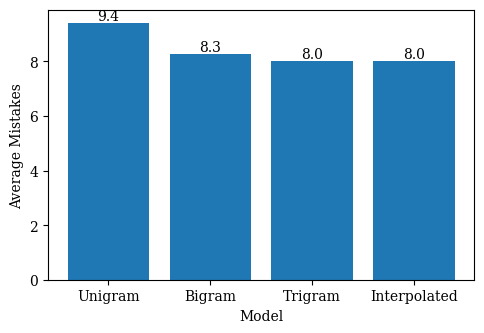

In [6]:
labels = []
mistakes = []
for name, lam in configs.items():
    avg = evaluate(test_set[:100], models, solver, lam)
    labels.append(name)
    mistakes.append(avg)

plt.bar(labels, mistakes)
for i, v in enumerate(mistakes):
    plt.text(i, v, f'{v:.1f}', ha='center', va='bottom')
plt.xlabel("Model")
plt.ylabel("Average Mistakes")
plt.savefig('mistakes_vs_model.pdf', bbox_inches='tight')
plt.show()

#remark: interpolated model uses trigram weights, as noted earlier so, this is an expected result.

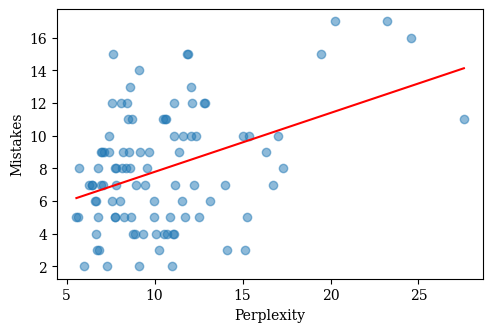

In [16]:
results = []
for word in test_set[:100]:
    m = play_game(word, models, solver, lambdas)
    pp = perplexity([word], models, lambdas)
    results.append((pp, m))

z = np.polyfit(pp_values, mistake_values, 1)
p = np.poly1d(z)
x_line = np.linspace(min(pp_values), max(pp_values), 100)

plt.scatter(pp_values, mistake_values, alpha=0.5)
plt.plot(x_line, p(x_line), color='red')
plt.xlabel("Perplexity")
plt.ylabel("Mistakes")
plt.savefig('perplexity_vs_mistakes.pdf', bbox_inches='tight')
plt.show()

#there was an outlier cooking the plot
#for pp, m in results:
#    if pp > 1000:
#        print(pp, m)

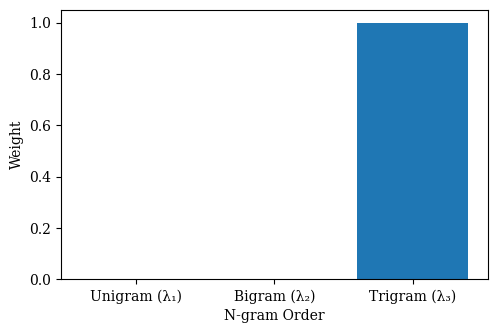

In [17]:
labels = ['Unigram (λ₁)', 'Bigram (λ₂)', 'Trigram (λ₃)']
weights = [lambdas[1], lambdas[2], lambdas[3]]

plt.bar(labels, weights)
#for i, v in enumerate(weights):
    #plt.text(i, v, f'{v:.1f}', ha='center', va='bottom')
plt.xlabel("N-gram Order")
plt.ylabel("Weight")
plt.savefig('lambda_weights.pdf', bbox_inches='tight')
plt.show()

#remark
#with a sufficiently large training corpus, the trigram model achieves strong enough coverage that lower-order backing off provides no additional benefit.
# maybe a smaller or more specialized corpus would result in the lambdas to be more distributed.

where does the model struggle

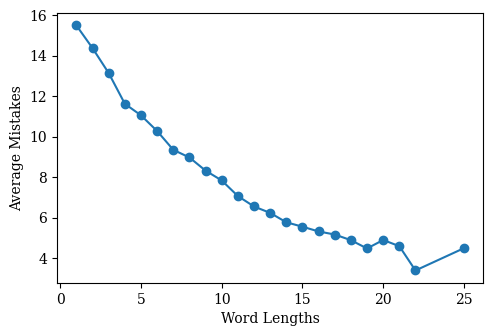

In [18]:
results = []
for word in test_set:
    m = play_game(word, models, solver, lambdas)
    results.append((len(word), m))
#print(results)

groups = {}
for length, m in results:
    if length not in groups:
        groups[length] = []
    groups[length].append(m)
#print(groups)
#remark, the discrepancy in mistakes for same length words may warrant looking at what words/letters the model struggles predicting.

avg_by_length = {}
for length, mistakes in groups.items():
    avg_by_length[length] = sum(mistakes) / len(mistakes)

lengths = sorted(avg_by_length.keys())
avgs = [avg_by_length[l] for l in lengths]

plt.plot(lengths, avgs, marker='o')
plt.xlabel("Word Lengths")
plt.ylabel("Average Mistakes")
#plt.savefig('length_vs_mistake.pdf', bbox_inches='tight')
plt.show()

#remark, Longer words might have more predictable parts like `tion', 'est' while 4 letter words are more unique and harder to predict
#the n-gram model benefits from longer words because more revealed characters provide richer context for predicting the remaining blanks

testing my lambda distribution hypothesis

In [20]:
fractions = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 1.0]
for frac in fractions:
    subset = train_set[:int(len(train_set) * frac)]
    models = {}
    for n in range(1, 4):
        padded = process(subset, n)
        models[n] = train(padded, n)
    lam = optimize_lambdas(held_out[:100], models, step=0.1)
    pp = perplexity(test_set[:100], models, lam)
    print(f"Training size: {len(subset)}, Lambdas: {lam}, Perplexity: {pp}")

Training size: 3164, Lambdas: {1: 0.09999999999999992, 2: 0.2, 3: 0.7000000000000001}, Perplexity: 10.57869812391268
Training size: 15821, Lambdas: {1: 0.09999999999999998, 2: 0.0, 3: 0.9}, Perplexity: 10.068174561590467
Training size: 31643, Lambdas: {1: 0.09999999999999998, 2: 0.0, 3: 0.9}, Perplexity: 9.971137453338745
Training size: 79109, Lambdas: {1: 0.0, 2: 0.0, 3: 1.0}, Perplexity: 10.176256510888942
Training size: 158219, Lambdas: {1: 0.0, 2: 0.0, 3: 1.0}, Perplexity: 9.977598187007445
Training size: 237329, Lambdas: {1: 0.0, 2: 0.0, 3: 1.0}, Perplexity: 9.965049327938118
Training size: 316439, Lambdas: {1: 0.0, 2: 0.0, 3: 1.0}, Perplexity: 9.962847065118684


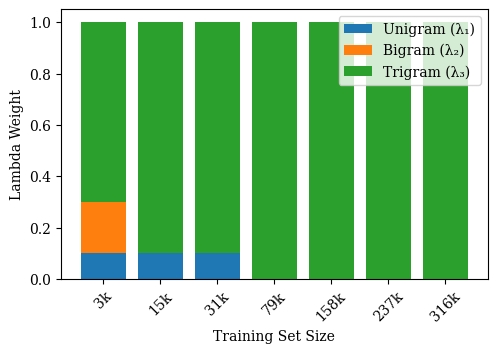

In [ ]:
#remark; indeed for smaller sets, distribution of lambda is more varied

sizes = [3164, 15821, 31643, 79109, 158219, 237329, 316439]
l1 = [0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0]
l2 = [0.2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
l3 = [0.7, 0.9, 0.9, 1.0, 1.0, 1.0, 1.0]

x = np.arange(len(sizes))
plt.bar(x, l1, label='Unigram (λ₁)')
plt.bar(x, l2, bottom=l1, label='Bigram (λ₂)')
plt.bar(x, l3, bottom=np.array(l1)+np.array(l2), label='Trigram (λ₃)')
plt.xticks(x, [f'{s//1000}k' for s in sizes], rotation=45)
plt.xlabel("Training Set Size")
plt.ylabel("Lambda Weight")
plt.legend()
plt.savefig('lambda_vs_training_size.pdf', bbox_inches='tight')
plt.show()

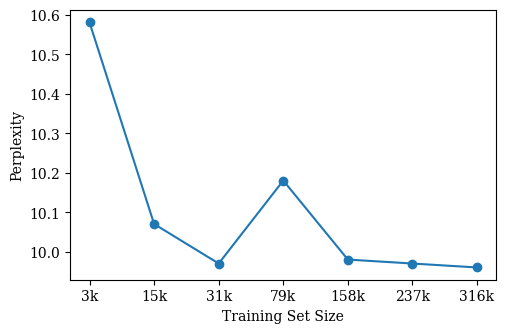

In [22]:
perplexities = [10.58, 10.07, 9.97, 10.18, 9.98, 9.97, 9.96]
sizes = [3164, 15821, 31643, 79109, 158219, 237329, 316439]

plt.plot([f'{s//1000}k' for s in sizes], perplexities, marker='o')
plt.xlabel("Training Set Size")
plt.ylabel("Perplexity")
plt.savefig('perplexity_vs_training_size.pdf', bbox_inches='tight')
plt.show()